#Evaluación Parcial 1 — Análisis Exploratorio y Preprocesamiento de Datos
## MLY0100 — Machine Learning

| **Dataset** : Natural Disasters|

| **Integrantes** : Diego Reyes Y Eva Luna Gonzalez Montes

| **Fecha** : Abril 2025 |

| **Metodología** : CRISP-DM


# FASE 1: Comprensión del Negocio

## Contexto
El dataset Natural Disasters proviene de EM-DAT (Emergency Events Database)
del CRED. Contiene registros históricos de desastres naturales a nivel mundial.

# FASE 2: Comprensión de los Datos

## Carga de librerías y datos
Se importan todas las librerías necesarias para el análisis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
df = pd.read_excel('sample_data/Natural-Disaster.xlsx') #creamos un dataframe llamado df y cargamos el dataset xlsx

In [3]:
pd.set_option('display.max_columns', None)  # muestra todas las columnas
pd.set_option('display.max_rows', None)     # muestra todas las filas
pd.set_option('display.width', None)        # no corta el ancho
pd.set_option('display.max_colwidth', None) # muestra el contenido completo de cada celda

df.head(5)

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,Subregion,Region,Location,Origin,Associated Types,OFDA/BHA Response,Appeal,Declaration,AID Contribution ('000 US$),Magnitude,Magnitude Scale,Latitude,Longitude,River Basin,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,United States of America,Northern America,Americas,Galveston (Texas),NaN,"Avalanche (Snow, Debris)",No,No,No,NaN,220.0,Kph,NaN,NaN,NaN,1900,9.0,8.0,1900,9.0,8.0,6000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30000.0,1131126.0,2.652223,NaN,NaN,2004-10-18,2023-10-17
1,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,Jamaica,Latin America and the Caribbean,Americas,Saint James,NaN,NaN,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,1900,1.0,6.0,1900,1.0,6.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
2,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,Jamaica,Latin America and the Caribbean,Americas,Porus,NaN,NaN,No,No,No,NaN,NaN,Vaccinated,NaN,NaN,NaN,1900,1.0,13.0,1900,1.0,13.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
3,1900-0008-JPN,Yes,nat-geo-vol-ash,Natural,Geophysical,Volcanic activity,Ash fall,NaN,NaN,JPN,Japan,Eastern Asia,Asia,NaN,NaN,NaN,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,1900,7.0,7.0,1900,7.0,7.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
4,1900-0009-TUR,Yes,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,NaN,NaN,TUR,Türkiye,Western Asia,Asia,"KARS,KARAKURT,KAGIZMAN,DIGOR",NaN,NaN,No,No,No,NaN,5.9,Moment Magnitude,40.3,43.1,NaN,1900,7.0,12.0,1900,7.0,12.0,140.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2019-08-05,2023-09-25


In [4]:
df.tail(5)  #visualizamos las ultimas 5 filas

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,Subregion,Region,Location,Origin,Associated Types,OFDA/BHA Response,Appeal,Declaration,AID Contribution ('000 US$),Magnitude,Magnitude Scale,Latitude,Longitude,River Basin,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
17786,2000-0036-CHN,No,nat-geo-ear-gro,Natural,Geophysical,Earthquake,Ground movement,USGS:usp0009mq6,NaN,CHN,China,Eastern Asia,Asia,"Mile Xian area (Honghe Hani and Yi district, Yunnan Sheng province), Qiubei Xian area (Wenshan Zhuang and Miao district, Yunnan Sheng province)",NaN,NaN,No,No,No,NaN,4.9,Moment Magnitude,24.263,103.797,NaN,2000,1.0,26.0,2000,1.0,26.0,1.0,2.0,10300.0,NaN,10302.0,NaN,NaN,NaN,NaN,483.0,880.0,54.895152,"[{""adm2_code"":13308,""adm2_name"":""Honghe Hani and Yi""},{""adm2_code"":13309,""adm2_name"":""Wenshan Zhuang and Miao""}]","[{""gid_2"":""CHN.30.13_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard2"",""name_2"":""Wenshan Zhuang and Miao""},{""gid_2"":""CHN.30.6_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard2"",""name_2"":""Honghe Hani and Yi""}]",2010-03-04,2025-12-20
17787,2000-0009-IRN,No,nat-met-sto-sto,Natural,Meteorological,Storm,Storm (General),NaN,NaN,IRN,Iran (Islamic Republic of),Southern Asia,Asia,Gilan province,NaN,Fire,No,No,No,NaN,120.0,Kph,NaN,NaN,NaN,2000,1.0,18.0,2000,1.0,18.0,3.0,NaN,NaN,5500.0,5500.0,NaN,NaN,NaN,NaN,NaN,NaN,54.895152,"[{""adm1_code"":1545,""adm1_name"":""Gilan""}]","[{""gid_1"":""IRN.8_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Gilan""}]",2003-07-01,2025-12-20
17788,1999-9388-UGA,Yes,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,UGA,Uganda,Sub-Saharan Africa,Africa,"Abim, Amudat, Kaabong, Kotido, Moroto, Nakapiripirit, Napak provinces",NaN,Famine,No,No,No,NaN,NaN,Km2,NaN,NaN,NaN,1999,8.0,NaN,2001,NaN,NaN,115.0,NaN,700000.0,NaN,700000.0,NaN,NaN,NaN,NaN,NaN,NaN,53.101972,"[{""adm1_code"":743,""adm1_name"":""Abim""},{""adm1_code"":744,""adm1_name"":""Amudat""},{""adm1_code"":765,""adm1_name"":""Kotido""},{""adm1_code"":772,""adm1_name"":""Moroto""},{""adm1_code"":773,""adm1_name"":""Nakapiripirit""},{""adm1_code"":775,""adm1_name"":""Napak""},{""adm1_code"":47074,""adm1_name"":""Kaabong""}]","[{""gid_2"":""UGA.28.1_1"",""migration_date"":""2025-12-20"",""migration_method"":""puzzle1_2"",""name_2"":""Dodoth""},{""gid_2"":""UGA.28.2_1"",""migration_date"":""2025-12-20"",""migration_method"":""puzzle1_2"",""name_2"":""Jie""},{""gid_2"":""UGA.28.3_1"",""migration_date"":""2025-12-20"",""migration_method"":""puzzle1_2"",""name_2"":""Labwor""},{""gid_2"":""UGA.40.1_1"",""migration_date"":""2025-12-20"",""migration_method"":""puzzle1_2"",""name_2"":""Bokora""},{""gid_2"":""UGA.40.2_1"",""migration_date"":""2025-12-20"",""migration_method"":""puzzle1_2"",""name_2"":""Matheniko""},{""gid_2"":""UGA.40.3_1"",""migration_date"":""2025-12-20"",""migration_method"":""puzzle1_2"",""name_2"":""Moroto""},{""gid_2"":""UGA.45.1_1"",""migration_date"":""2025-12-20"",""migration_method"":""puzzle1_2"",""name_2"":""Chekwii""},{""gid_2"":""UGA.45.2_1"",""migration_date"":""2025-12-20"",""migration_method"":""puzzle1_2"",""name_2"":""Pian""},{""gid_2"":""UGA.45.3_1"",""migration_date"":""2025-12-20"",""migration_method"":""puzzle1_2"",""name_2"":""Pokot""}]",2006-03-08,2025-12-20
17789,1999-9388-SOM,No,nat-cli-dro-dro,Natural,Climatological,Drought,Drought,NaN,NaN,SOM,Somalia,Sub-Saharan Africa,Africa,"Ceel Barde, Rab Dhuure, Tayeeglow, Xudur districts (Bakool province), Garbahaarey, Baardheere districts (Gedo pr

In [5]:
df.shape #devuelve la cantidad de filas y columnas respectivamente

(17791, 47)

In [6]:
df.dtypes #observamos la columna y sus tipos de datos

,0
DisNo.,object
Historic,object
Classification Key,object
Disaster Group,object
Disaster Subgroup,object
Disaster Type,object
Disaster Subtype,object
External IDs,object
Event Name,object
ISO,object


In [7]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
DisNo.,0
Historic,0
Classification Key,0
Disaster Group,0
Disaster Subgroup,0
Disaster Type,0
Disaster Subtype,0
External IDs,13190
Event Name,13464
ISO,0


In [8]:
# Porcentaje de nulos por columna
nulos = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print(nulos[nulos > 0].to_string())

Reconstruction Costs, Adjusted ('000 US$)    99.78
Reconstruction Costs ('000 US$)              99.77
AID Contribution ('000 US$)                  95.64
Insured Damage, Adjusted ('000 US$)          93.61
Insured Damage ('000 US$)                    93.55
River Basin                                  90.99
No. Homeless                                 85.70
Longitude                                    84.06
Latitude                                     84.06
Associated Types                             75.90
Event Name                                   75.68
External IDs                                 74.14
No. Injured                                  73.73
Origin                                       73.42
Magnitude                                    70.24
Total Damage, Adjusted ('000 US$)            68.32
Total Damage ('000 US$)                      67.83
GADM Admin Units                             56.09
Admin Units                                  52.94
No. Affected                   

Observamos que el Si más del 50% de una columna es nula, hay más huecos que datos reales. Cualquier análisis sobre esa columna estaría basado en minoría de información. Es por eso que decidimos borrar esas columnas

In [9]:
# 1. Eliminar columnas con >50% nulos
umbral = 0.50
cols_drop = df.columns[df.isna().mean() > umbral].tolist()
# También eliminar columnas identificadoras sin valor predictivo
cols_id = ['DisNo.', 'Historic', 'Classification Key', 'External IDs',
           'Event Name', 'Admin Units', 'GADM Admin Units',
           'Entry Date', 'Last Update', 'ISO']
cols_drop = list(set(cols_drop + [c for c in cols_id if c in df.columns]))
df.drop(columns=cols_drop, inplace=True)

print(f'Columnas eliminadas: {len(cols_drop)}')
print(f'Columnas restantes: {df.shape[1]}')
print(f'Columnas eliminadas: {cols_drop}')

Columnas eliminadas: 25
Columnas restantes: 22
Columnas eliminadas: ['Magnitude', "Total Damage ('000 US$)", 'Classification Key', "AID Contribution ('000 US$)", 'Historic', "Insured Damage ('000 US$)", 'Event Name', 'External IDs', 'ISO', 'Admin Units', 'No. Injured', 'No. Homeless', 'Last Update', 'Origin', "Insured Damage, Adjusted ('000 US$)", 'Longitude', 'Entry Date', 'River Basin', "Reconstruction Costs, Adjusted ('000 US$)", "Reconstruction Costs ('000 US$)", 'Latitude', "Total Damage, Adjusted ('000 US$)", 'Associated Types', 'DisNo.', 'GADM Admin Units']


In [10]:
# Tipos de variables
print("Variables numéricas:")
print(df.select_dtypes(include='number').columns.tolist())

print("\nVariables categóricas (object):")
print(df.select_dtypes(include='object').columns.tolist())

Variables numéricas:
['Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Affected', 'Total Affected', 'CPI']

Variables categóricas (object):
['Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'Country', 'Subregion', 'Region', 'Location', 'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude Scale']


In [11]:
df.columns #mostramos los nombres de las columnas

Index(['Disaster Group', 'Disaster Subgroup', 'Disaster Type',
       'Disaster Subtype', 'Country', 'Subregion', 'Region', 'Location',
       'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude Scale',
       'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month',
       'End Day', 'Total Deaths', 'No. Affected', 'Total Affected', 'CPI'],
      dtype='object')

## Mapeo de Variables

**Categóricas Nominales**
- Disaster Group: Categórico Nominal
- Disaster Subgroup: Categórico Nominal
- Disaster Type: Categórico Nominal
- Disaster Subtype: Categórico Nominal
- Country: Categórico Nominal
- Subregion: Categórico Nominal
- Region: Categórico Nominal
- Location: Categórico Nominal
- OFDA/BHA Response: Categórico Nominal
- Appeal: Categórico Nominal
- Declaration: Categórico Nominal

**Categóricas Ordinales**
- Magnitude Scale: Categórico Ordinal

**Numéricas Discretas**
- Start Year: Numérico Discreto
- Start Month: Numérico Discreto
- Start Day: Numérico Discreto
- End Year: Numérico Discreto
- End Month: Numérico Discreto
- End Day: Numérico Discreto
- Total Deaths: Numérico Discreto
- No. Affected: Numérico Discreto
- Total Affected: Numérico Discreto

**Numéricas Continuas**
- CPI: Numérico Continuo

**Clasificacion de Variables**
- Categorico Nominal: Categorias sin un orden o jerarquia especifica.
- Categorico Ordinal: Categorias que siguen un orden logico o escala.
- Numerico Discreto: Valores que surgen de un conteo y no admiten decimales.
- Numerico Continuo: Valores que resultan de una medicion y pueden tener decimales infinitos.

In [12]:
cant_cat_col_Disaster_Group_df = df['Disaster Subgroup'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de region
print(cant_cat_col_Disaster_Group_df)

# Imprimimos la cantidad total de categorias unicas
print(f"cantidad de sub grupo de desastres naturales: {cant_cat_col_Disaster_Group_df.count()}")

Disaster Subgroup
Hydrological         7060
Meteorological       5800
Geophysical          1981
Biological           1622
Climatological       1327
Extra-terrestrial       1
Name: count, dtype: int64
cantidad de sub grupo de desastres naturales: 6


tenemos 6 sub grupo de desastres naturales

In [13]:
cant_cat_col_Disaster_Group_df = df['Disaster Type'].value_counts()#nos mostrará la cantidad de categoricas distintas unicas de region
print(cant_cat_col_Disaster_Group_df)

# Imprimimos la cantidad total de categorias unicas
print(f"cantidad de tipos de desastres naturales: {cant_cat_col_Disaster_Group_df.count()}")


Disaster Type
Flood                          6187
Storm                          5070
Earthquake                     1653
Epidemic                       1526
Mass movement (wet)             873
Drought                         804
Extreme temperature             729
Wildfire                        515
Volcanic activity               282
Infestation                      95
Mass movement (dry)              46
Glacial lake outburst flood       8
Fog                               1
Animal incident                   1
Impact                            1
Name: count, dtype: int64
cantidad de tipos de desastres naturales: 15


tenemos 15 tipos de desastres naturales

Estadistica descriptiva a las variables numericas

In [14]:
df.describe()

,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Affected,Total Affected,CPI
count,17791.000000,17419.000000,14189.000000,17791.000000,17126.000000,14298.000000,1.280000e+04,1.063200e+04,1.322500e+04,17348.000000
mean,1999.591591,6.451174,15.210656,1999.644820,6.606855,15.842216,2.562424e+03,8.282592e+05,6.805070e+05,56.548886
std,21.025096,3.383710,8.967611,21.014338,3.352132,8.901543,6.478984e+04,8.025160e+06,7.270227e+06,24.643844
min,1900.000000,1.000000,1.000000,1900.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,2.652223
25%,1991.000000,4.000000,7.000000,1991.000000,4.000000,8.000000,5.000000e+00,1.299500e+03,7.000000e+02,41.652196
50%,2004.000000,7.000000,15.000000,2004.000000,7.000000,16.000000,1.800000e+01,1.000000e+04,6.000000e+03,58.643553
75%,2015.000000,9.000000,23.000000,2015.000000,9.000000,24.000000,6.000000e+01,9.295125e+04,6.000000e+04,75.468456
max,2026.000000,12.000000,31.000000,2026.000000,12.000000,31.000000,3.700000e+06,3.300000e+08,3.300000e+08,100.000000


Importaremos las librerias para realizar el encoder a Disaster Subgroup y Disaster Type

In [15]:
pip install category_encoders

In [16]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [17]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 1. OneHotEncoder para 'Disaster Subgroup' (6 categorías)
ohe_subgroup = OneHotEncoder(sparse_output=False)
subgroup_encoded = ohe_subgroup.fit_transform(df[['Disaster Subgroup']])

subgroup_df = pd.DataFrame(
    subgroup_encoded,
    columns=ohe_subgroup.get_feature_names_out(['Disaster Subgroup']),
    index=df.index
)

# 2. OneHotEncoder para 'Disaster Type' (15 categorías)
ohe_type = OneHotEncoder(sparse_output=False)
type_encoded = ohe_type.fit_transform(df[['Disaster Type']])

type_df = pd.DataFrame(
    type_encoded,
    columns=ohe_type.get_feature_names_out(['Disaster Type']),
    index=df.index
)

# 3. Concatenar todo y eliminar columnas originales
df_final = pd.concat(
    [df.drop(columns=['Disaster Subgroup', 'Disaster Type']), subgroup_df, type_df],
    axis=1
)

# 4. Ver resultados
print(df_final.head())
print(f"Total de columnas tras el encoding: {len(df_final.columns)}")

  Disaster Group  Disaster Subtype                   Country  \
0        Natural  Tropical cyclone  United States of America   
1        Natural   Flood (General)                   Jamaica   
2        Natural     Viral disease                   Jamaica   
3        Natural          Ash fall                     Japan   
4        Natural   Ground movement                   Türkiye   

                         Subregion    Region                      Location  \
0                 Northern America  Americas             Galveston (Texas)   
1  Latin America and the Caribbean  Americas                   Saint James   
2  Latin America and the Caribbean  Americas                         Porus   
3                     Eastern Asia      Asia                           NaN   
4                     Western Asia      Asia  KARS,KARAKURT,KAGIZMAN,DIGOR   

  OFDA/BHA Response Appeal Declaration   Magnitude Scale  Start Year  \
0                No     No          No               Kph        1900   
1 

In [18]:
df_final.head(100) #observamos el nuevo dataframe con las variables y encoder aplicado

,Disaster Group,Disaster Subtype,Country,Subregion,Region,Location,OFDA/BHA Response,Appeal,Declaration,Magnitude Scale,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Affected,Total Affected,CPI,Disaster Subgroup_Biological,Disaster Subgroup_Climatological,Disaster Subgroup_Extra-terrestrial,Disaster Subgroup_Geophysical,Disaster Subgroup_Hydrological,Disaster Subgroup_Meteorological,Disaster Type_Animal incident,Disaster Type_Drought,Disaster Type_Earthquake,Disaster Type_Epidemic,Disaster Type_Extreme temperature,Disaster Type_Flood,Disaster Type_Fog,Disaster Type_Glacial lake outburst flood,Disaster Type_Impact,Disaster Type_Infestation,Disaster Type_Mass movement (dry),Disaster Type_Mass movement (wet),Disaster Type_Storm,Disaster Type_Volcanic activity,Disaster Type_Wildfire
0,Natural,Tropical cyclone,United States of America,Northern America,Americas,Galveston (Texas),No,No,No,Kph,1900,9.0,8.0,1900,9.0,8.0,6000.0,NaN,NaN,2.652223,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Natural,Flood (General),Jamaica,Latin America and the Caribbean,Americas,Saint James,No,No,No,Km2,1900,1.0,6.0,1900,1.0,6.0,300.0,NaN,NaN,2.652223,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Natural,Viral disease,Jamaica,Latin America and the Caribbean,Americas,Porus,No,No,No,Vaccinated,1900,1.0,13.0,1900,1.0,13.0,30.0,NaN,NaN,2.652223,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Natural,Ash fall,Japan,Eastern Asia,Asia,NaN,No,No,No,NaN,1900,7.0,7.0,1900,7.0,7.0,30.0,NaN,NaN,2.652223,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,Natural,Ground movement,Türkiye,Western Asia,Asia,"KARS,KARAKURT,KAGIZMAN,DIGOR",No,No,No,Moment Magnitude,1900,7.0,12.0,1900,7.0,12.0,140.0,NaN,NaN,2.652223,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Natural,Drought,India,Southern Asia,Asia,Bengal,No,No,No,Km2,1900,NaN,NaN,1900,NaN,NaN,1250000.0,NaN,NaN,2.652223,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Natural,Drought,Cabo Verde,Sub-Saharan Africa,Africa,Countrywide,No,No,No,Km2,1900,NaN,NaN,1900,NaN,NaN,11000.0,NaN,NaN,2.652223,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Natural,Infectious disease (General),Uganda,Sub-Saharan Africa,Africa,Nationwide,No,No,No,Vaccinated,1901,NaN,NaN,1901,NaN,NaN,200000.0,NaN,NaN,2.652223,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Natural,Tsunami,Japan,Eastern Asia,Asia,Sanriku,No,No,No,Moment Magnitude,1901,8.0,10.0,1901,8.0,10.0,18.0,NaN,24.0,2.652223,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Natural,Ash fall,Guatemala,Latin America and the Caribbean,Americas,NaN,No,No,No,NaN,1902,4.0,8.0,1902,4.0,8.0,1000.0,NaN,NaN,2.758312,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [19]:
df_final.describe()

,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Affected,Total Affected,CPI,Disaster Subgroup_Biological,Disaster Subgroup_Climatological,Disaster Subgroup_Extra-terrestrial,Disaster Subgroup_Geophysical,Disaster Subgroup_Hydrological,Disaster Subgroup_Meteorological,Disaster Type_Animal incident,Disaster Type_Drought,Disaster Type_Earthquake,Disaster Type_Epidemic,Disaster Type_Extreme temperature,Disaster Type_Flood,Disaster Type_Fog,Disaster Type_Glacial lake outburst flood,Disaster Type_Impact,Disaster Type_Infestation,Disaster Type_Mass movement (dry),Disaster Type_Mass movement (wet),Disaster Type_Storm,Disaster Type_Volcanic activity,Disaster Type_Wildfire
count,17791.000000,17419.000000,14189.000000,17791.000000,17126.000000,14298.000000,1.280000e+04,1.063200e+04,1.322500e+04,17348.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.000000,17791.00000,17791.000000,17791.00000,17791.000000,17791.000000,17791.000000
mean,1999.591591,6.451174,15.210656,1999.644820,6.606855,15.842216,2.562424e+03,8.282592e+05,6.805070e+05,56.548886,0.091170,0.074588,0.000056,0.111348,0.396830,0.326008,0.000056,0.045191,0.092912,0.085774,0.040976,0.347760,0.000056,0.000450,0.000056,0.00534,0.002586,0.04907,0.284976,0.015851,0.028947
std,21.025096,3.383710,8.967611,21.014338,3.352132,8.901543,6.478984e+04,8.025160e+06,7.270227e+06,24.643844,0.287858,0.262733,0.007497,0.314572,0.489254,0.468763,0.007497,0.207730,0.290317,0.280037,0.198240,0.476273,0.007497,0.021201,0.007497,0.07288,0.050784,0.21602,0.451415,0.124901,0.167663
min,1900.000000,1.000000,1.000000,1900.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,2.652223,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1991.000000,4.000000,7.000000,1991.000000,4.000000,8.000000,5.000000e+00,1.299500e+03,7.000000e+02,41.652196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,2004.000000,7.000000,15.000000,2004.000000,7.000000,16.000000,1.800000e+01,1.000000e+04,6.000000e+03,58.643553,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,2015.000000,9.000000,23.000000,2015.000000,9.000000,24.000000,6.000000e+01,9.295125e+04,6.000000e+04,75.468456,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,1.000000,0.000000,0.000000
max,2026.000000,12.000000,31.000000,2026.000000,12.000000,31.000000,3.700000e+06,3.300000e+08,3.300000e+08,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000


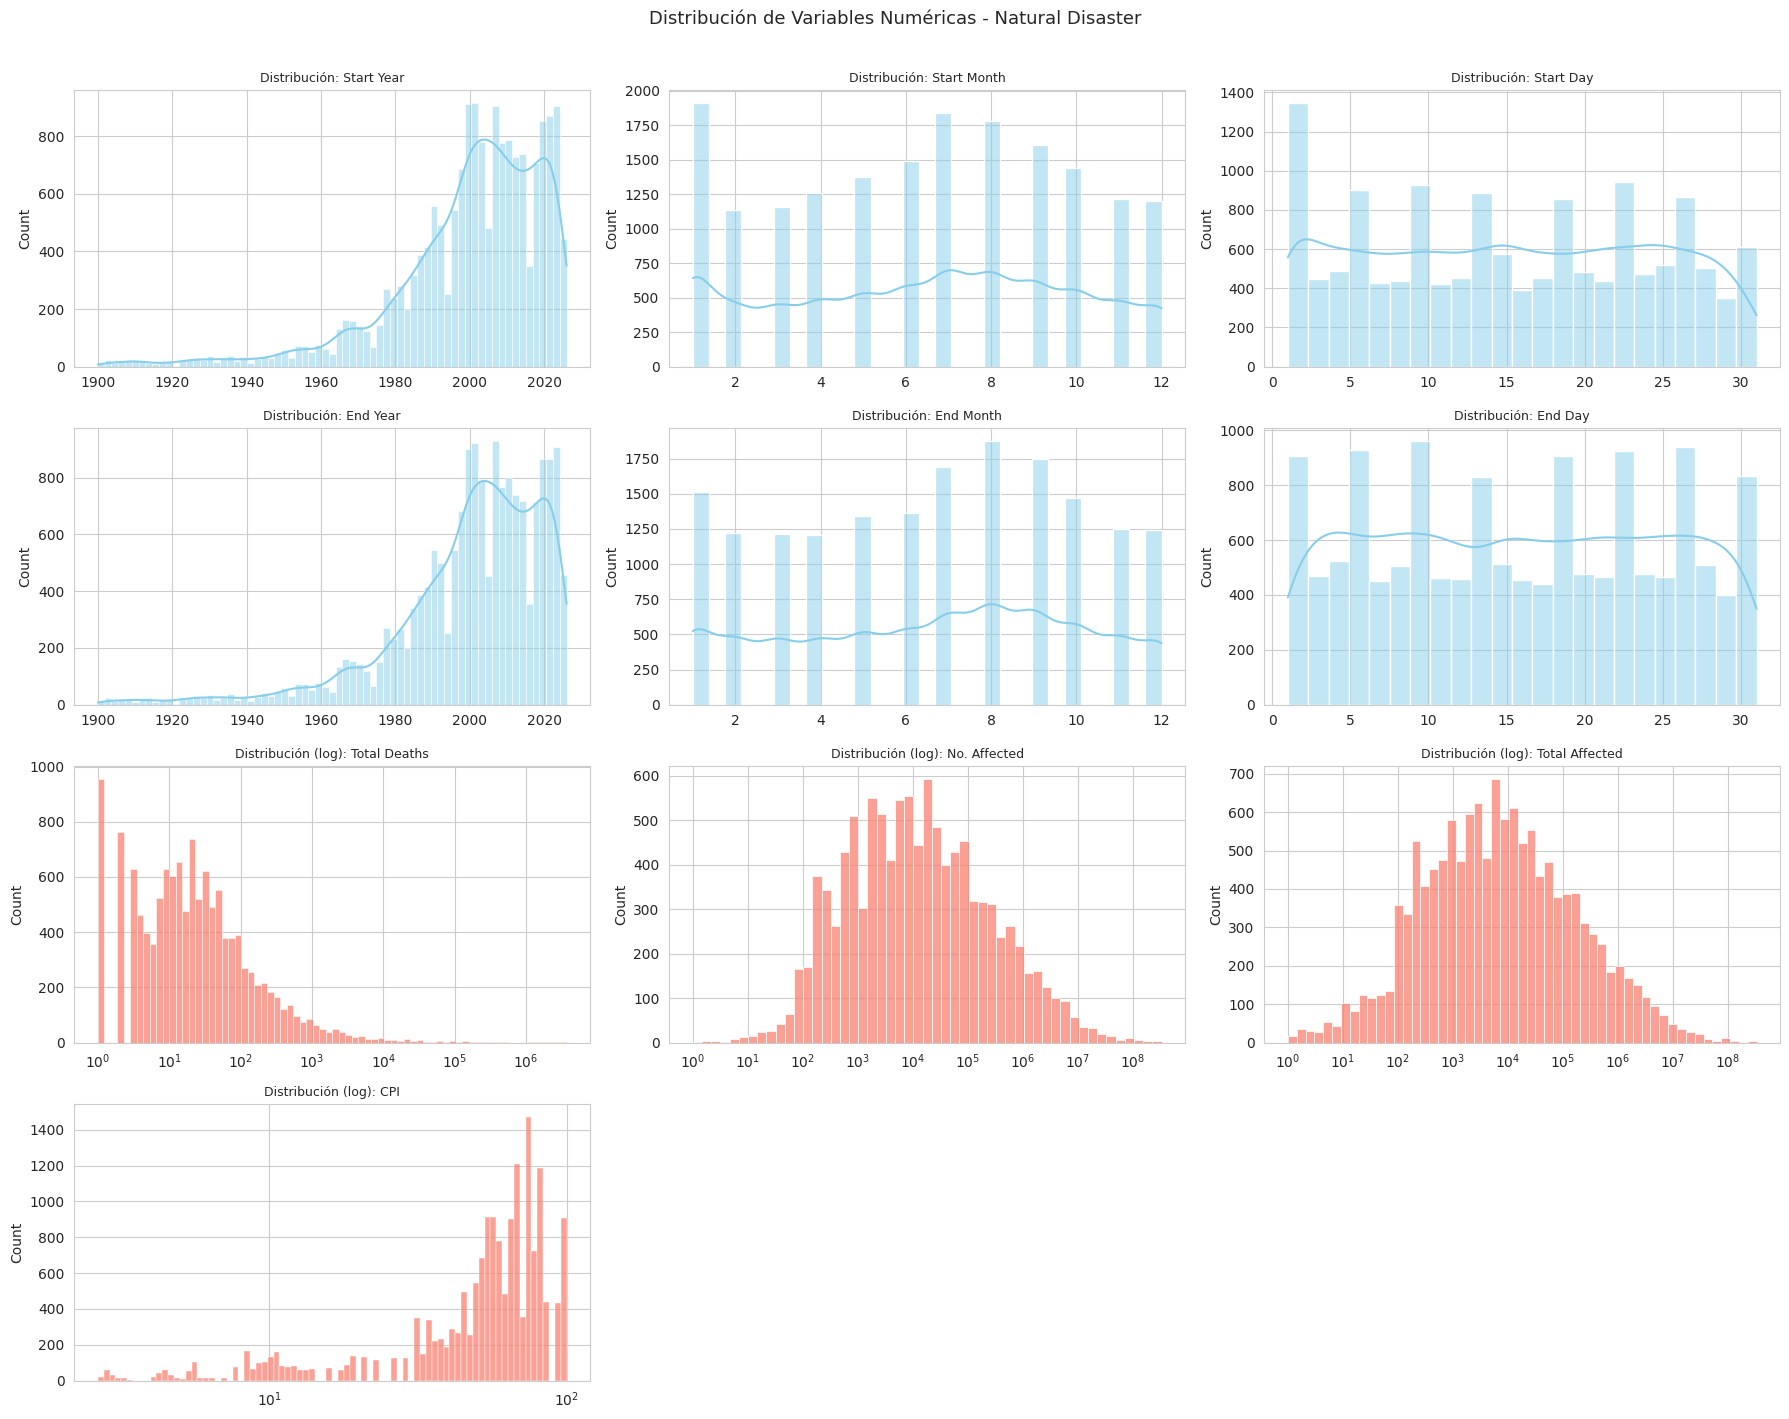

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Columnas con distribución muy sesgada (sin KDE, con escala log)
cols_skewed = ['Total Deaths', 'No. Affected', 'Total Affected', 'CPI']

# Columnas normales (fechas, con KDE normal)
cols_normales = [
    'Start Year', 'Start Month', 'Start Day',
    'End Year', 'End Month', 'End Day'
]

plt.figure(figsize=(18, 14))

# Graficamos las normales con KDE
for i, col in enumerate(cols_normales, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribución: {col}', fontsize=9)
    plt.xlabel('')

# Graficamos las sesgadas sin KDE y con log scale
for j, col in enumerate(cols_skewed, len(cols_normales) + 1):
    plt.subplot(4, 3, j)
    data = df[col].dropna()
    data = data[data > 0]  # log no acepta 0 ni negativos
    sns.histplot(data, kde=False, color='salmon', log_scale=True)
    plt.title(f'Distribución (log): {col}', fontsize=9)
    plt.xlabel('')

plt.suptitle('Distribución de Variables Numéricas - Natural Disaster', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

##Interpretación de la Distribución de Variables Numéricas

###Variables Temporales (Start/End Year, Month, Day)

**Start Year / End Year**
Ambos gráficos muestran un fuerte sesgo hacia la derecha: la mayoría de los
registros se concentran entre 1980 y 2024. Esto no necesariamente indica que
los desastres naturales sean más frecuentes hoy, sino que los sistemas de
registro y reporte han mejorado significativamente en las últimas décadas.
Antes de 1950 los datos son escasos y poco confiables.

**Start Month / End Month**
La distribución es relativamente uniforme a lo largo del año, con un leve
aumento en los meses 7 y 8 (julio-agosto). Esto es coherente con la
temporada de huracanes en el Atlántico Norte y las tormentas monzónicas en
Asia. No se observa un mes claramente dominante.

**Start Day / End Day**
La distribución es prácticamente plana, lo que es esperable: los desastres
no tienen preferencia por un día del mes en particular. La leve caída al
final del eje (días 29-31) se explica por que no todos los meses tienen
esos días.

---

###Variables de Impacto en escala logarítmica (Total Deaths, No. Affected, Total Affected)

Estas tres variables se graficaron en **escala logarítmica** debido a su
distribución extremadamente sesgada: la mayoría de los desastres tienen
un impacto relativamente bajo, pero unos pocos eventos catastrófico
(como el terremoto de Haití 2010 o el tsunami de 2004) registran cifras
enormes que distorsionan la escala normal.

**Total Deaths**
En escala log se observa una distribución aproximadamente normal, lo que
confirma que la variable sigue una distribución log-normal. La mayoría
de los desastres causa entre 1 y 1.000 muertes, con muy pocos eventos
superando las 100.000 víctimas fatales.

**No. Affected**
Similar comportamiento log-normal. Representa el número de personas
directamente afectadas (heridos, desplazados, sin hogar). Los valores
se concentran entre miles y millones, con eventos extremos que superan
los 100 millones de afectados.

**Total Affected**
Es la suma de todas las personas impactadas de cualquier forma por el
desastre. Muestra la misma forma log-normal, con alta concentración en
rangos medios y una cola derecha extensa que representa los mega-desastres.

---

###Conclusión general
Las variables temporales presentan distribuciones esperables y sin grandes
anomalías. Las variables de impacto humano (muertes y afectados) siguen
distribuciones log-normales típicas de fenómenos naturales extremos, donde
la mayoría de eventos son moderados pero unos pocos concentran el mayor
daño. Esto tiene implicancias importantes para el modelado: estas variables
deberán ser transformadas (por ejemplo con log1p) antes de usarlas en
algoritmos de Machine Learning.

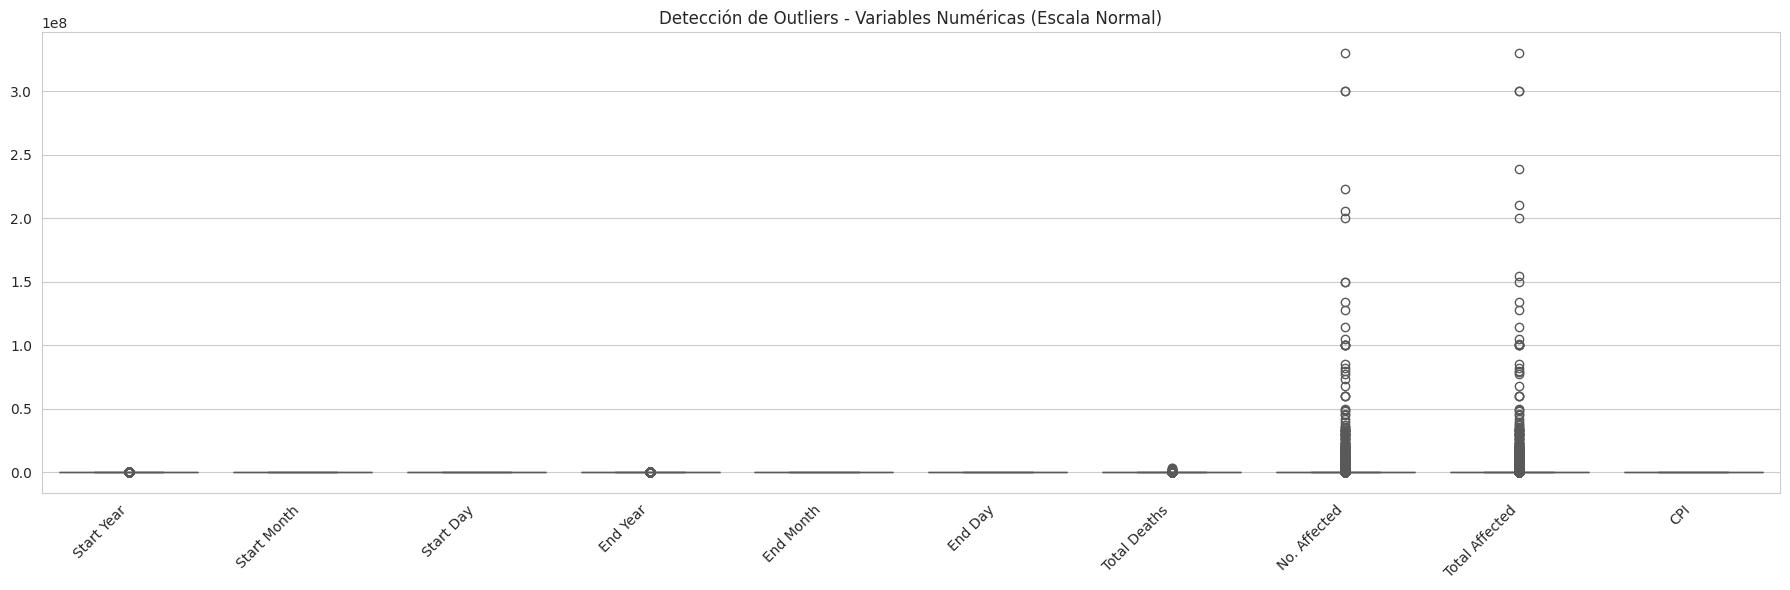

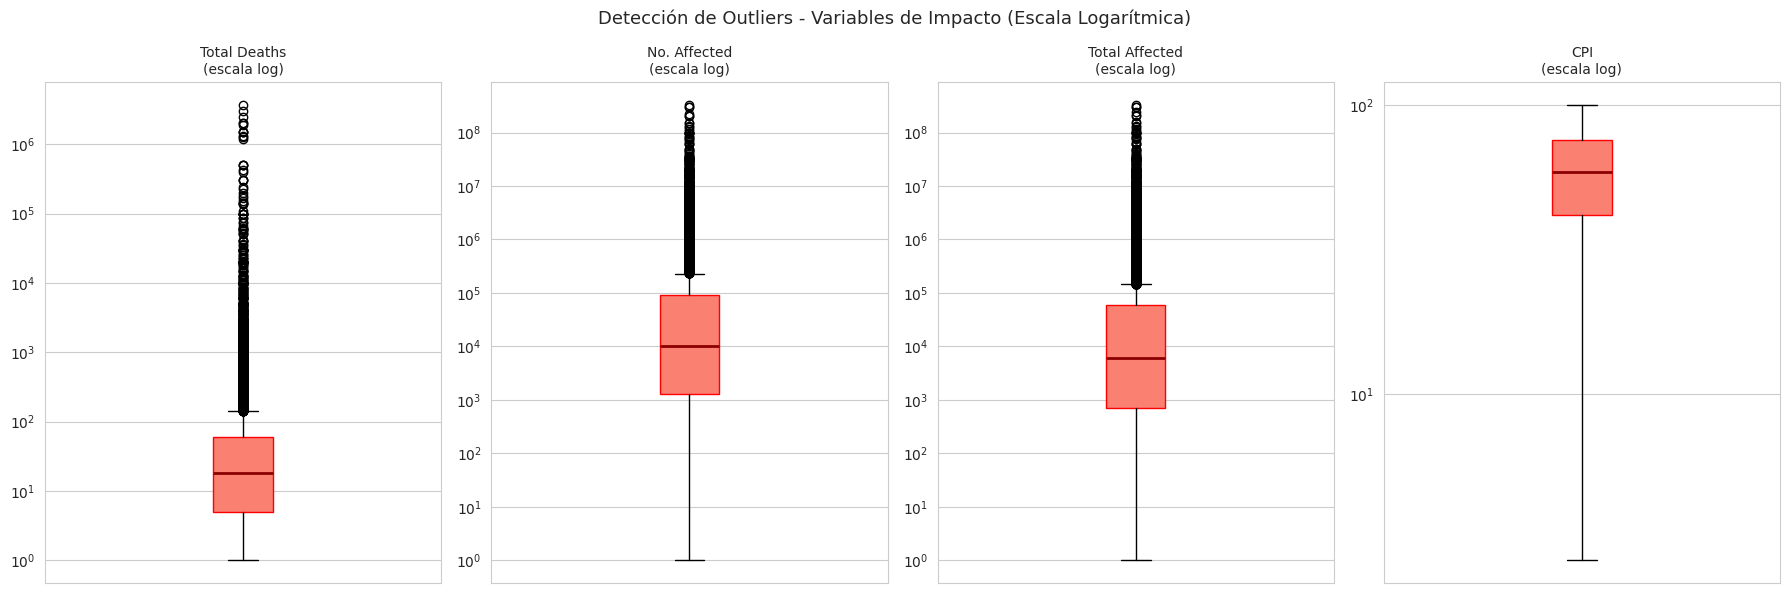

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columnas numéricas del dataset Natural Disaster
cols_numericas = [
    'Start Year', 'Start Month', 'Start Day',
    'End Year', 'End Month', 'End Day',
    'Total Deaths', 'No. Affected', 'Total Affected', 'CPI'
]

# ── 1. Boxplot general (escala normal) ──────────────────────────────────────
plt.figure(figsize=(18, 6))
sns.boxplot(data=df[cols_numericas], palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Detección de Outliers - Variables Numéricas (Escala Normal)')
plt.tight_layout()
plt.show()

# ── 2. Boxplot separado para variables de impacto (escala log) ──────────────
cols_impacto = ['Total Deaths', 'No. Affected', 'Total Affected', 'CPI']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for ax, col in zip(axes, cols_impacto):
    data = df[col].dropna()
    data = data[data > 0]  # escala log no acepta 0
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor='salmon', color='red'),
               medianprops=dict(color='darkred', linewidth=2))
    ax.set_yscale('log')
    ax.set_title(f'{col}\n(escala log)', fontsize=10)
    ax.set_xticks([])

fig.suptitle('Detección de Outliers - Variables de Impacto (Escala Logarítmica)', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler

# 1. Columnas numéricas a estandarizar
cols_a_escalar = [
    'Start Year', 'Start Month', 'Start Day',
    'End Year', 'End Month', 'End Day',
    'Total Deaths', 'No. Affected', 'Total Affected', 'CPI'
]

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Aplicamos el escalamiento sobre df_final (resultado del encoding anterior)
df_final_esc = df_final.copy()
df_final_esc[cols_a_escalar] = scaler.fit_transform(df_final[cols_a_escalar])

# 4. Verificación
print("Primeras 5 filas con datos estandarizados:")
print(df_final_esc[cols_a_escalar].head())

print("\nEstadísticas tras estandarización (media ≈ 0, std ≈ 1):")
print(df_final_esc[cols_a_escalar].describe().round(3))

Primeras 5 filas con datos estandarizados:
   Start Year  Start Month  Start Day  End Year  End Month   End Day  \
0   -4.736929     0.753285  -0.804106 -4.741887   0.713938 -0.881026   
1   -4.736929    -1.611052  -1.027139 -4.741887  -1.672673 -1.105714   
2   -4.736929    -1.611052  -0.246524 -4.741887  -1.672673 -0.319306   
3   -4.736929     0.162201  -0.915622 -4.741887   0.117285 -0.993370   
4   -4.736929     0.162201  -0.358041 -4.741887   0.117285 -0.431650   

   Total Deaths  No. Affected  Total Affected       CPI  
0      0.053059           NaN             NaN -2.187086  
1     -0.034921           NaN             NaN -2.187086  
2     -0.039088           NaN             NaN -2.187086  
3     -0.039088           NaN             NaN -2.187086  
4     -0.037390           NaN             NaN -2.187086  

Estadísticas tras estandarización (media ≈ 0, std ≈ 1):
       Start Year  Start Month  Start Day   End Year  End Month    End Day  \
count   17791.000    17419.000  14189.000

In [23]:
df_final_esc.head()

,Disaster Group,Disaster Subtype,Country,Subregion,Region,Location,OFDA/BHA Response,Appeal,Declaration,Magnitude Scale,Start Year,Start Month,Start Day,End Year,End Month,End Day,Total Deaths,No. Affected,Total Affected,CPI,Disaster Subgroup_Biological,Disaster Subgroup_Climatological,Disaster Subgroup_Extra-terrestrial,Disaster Subgroup_Geophysical,Disaster Subgroup_Hydrological,Disaster Subgroup_Meteorological,Disaster Type_Animal incident,Disaster Type_Drought,Disaster Type_Earthquake,Disaster Type_Epidemic,Disaster Type_Extreme temperature,Disaster Type_Flood,Disaster Type_Fog,Disaster Type_Glacial lake outburst flood,Disaster Type_Impact,Disaster Type_Infestation,Disaster Type_Mass movement (dry),Disaster Type_Mass movement (wet),Disaster Type_Storm,Disaster Type_Volcanic activity,Disaster Type_Wildfire
0,Natural,Tropical cyclone,United States of America,Northern America,Americas,Galveston (Texas),No,No,No,Kph,-4.736929,0.753285,-0.804106,-4.741887,0.713938,-0.881026,0.053059,NaN,NaN,-2.187086,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Natural,Flood (General),Jamaica,Latin America and the Caribbean,Americas,Saint James,No,No,No,Km2,-4.736929,-1.611052,-1.027139,-4.741887,-1.672673,-1.105714,-0.034921,NaN,NaN,-2.187086,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Natural,Viral disease,Jamaica,Latin America and the Caribbean,Americas,Porus,No,No,No,Vaccinated,-4.736929,-1.611052,-0.246524,-4.741887,-1.672673,-0.319306,-0.039088,NaN,NaN,-2.187086,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Natural,Ash fall,Japan,Eastern Asia,Asia,NaN,No,No,No,NaN,-4.736929,0.162201,-0.915622,-4.741887,0.117285,-0.993370,-0.039088,NaN,NaN,-2.187086,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,Natural,Ground movement,Türkiye,Western Asia,Asia,"KARS,KARAKURT,KAGIZMAN,DIGOR",No,No,No,Moment Magnitude,-4.736929,0.162201,-0.358041,-4.741887,0.117285,-0.431650,-0.037390,NaN,NaN,-2.187086,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Hacer una copia para no alterar df_final_esc
df_corr = df_final_esc.copy()

# 2. Identificar columnas categóricas restantes
cols_categoricas = df_corr.select_dtypes(include='object').columns.tolist()
print("Columnas categóricas a encodear:", cols_categoricas)

# 3. Aplicar LabelEncoder a cada una
le = LabelEncoder()
for col in cols_categoricas:
    df_corr[col] = df_corr[col].fillna('Desconocido')  # rellenar NaN antes de encodear
    df_corr[col] = le.fit_transform(df_corr[col])

# 4. Verificar que ya no queden objetos
print("Tipos restantes:", df_corr.dtypes.value_counts())
print("Shape:", df_corr.shape)

Columnas categóricas a encodear: ['Disaster Group', 'Disaster Subtype', 'Country', 'Subregion', 'Region', 'Location', 'OFDA/BHA Response', 'Appeal', 'Declaration', 'Magnitude Scale']
Tipos restantes: float64    31
int64      10
Name: count, dtype: int64
Shape: (17791, 41)


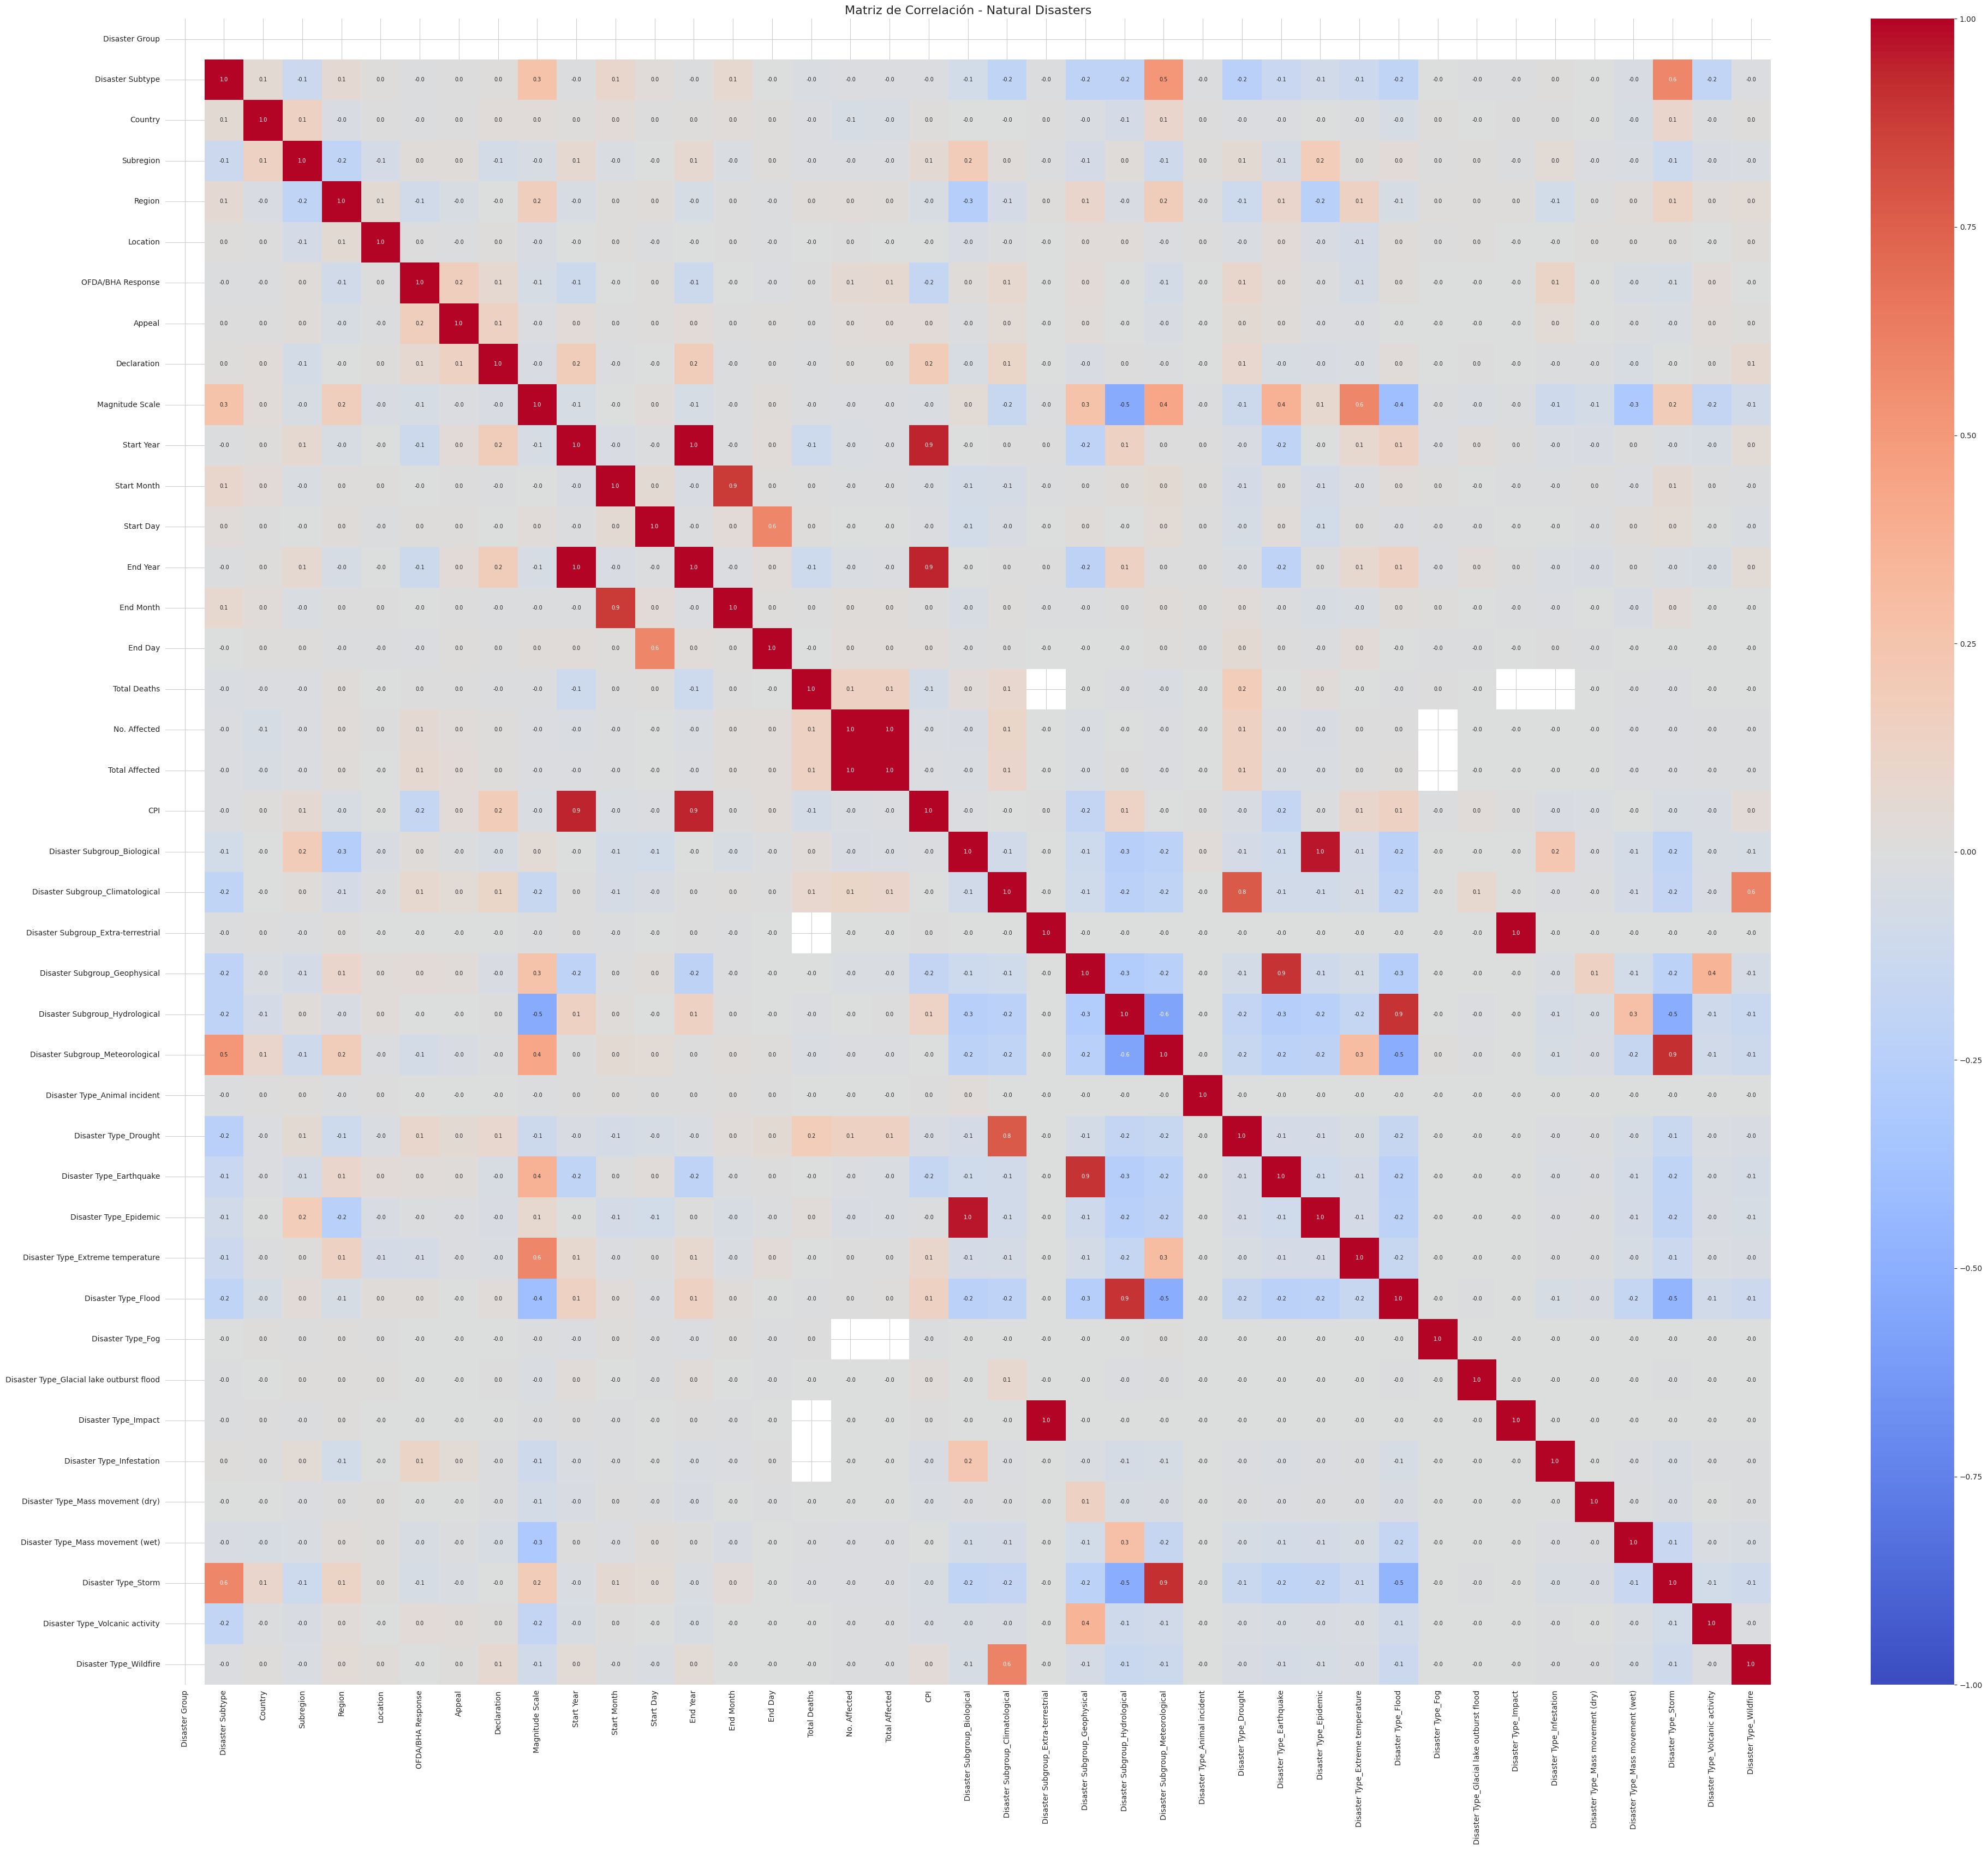

In [25]:
corr_matrix = df_corr.corr()

plt.figure(figsize=(40, 34))
sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=+1,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7},
    cmap="coolwarm"
)
plt.title("Matriz de Correlación - Natural Disasters", fontsize=16)
plt.tight_layout()
plt.show()

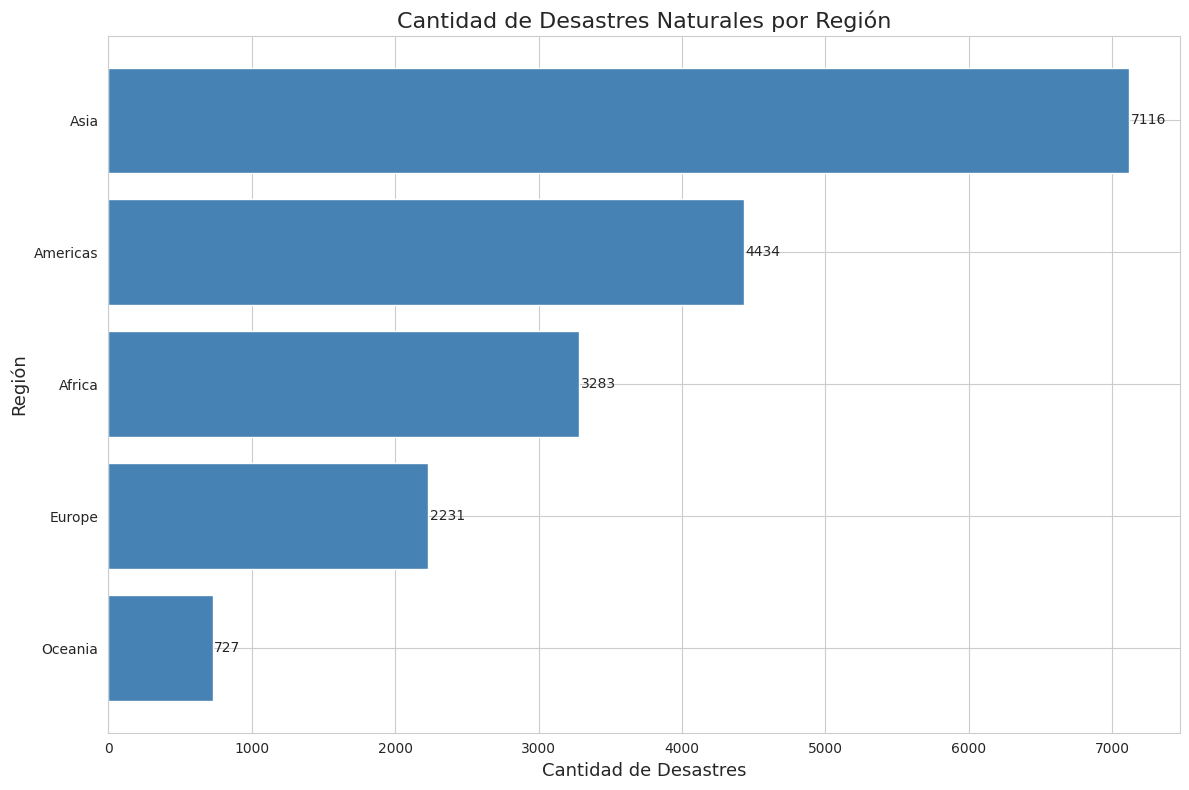

In [26]:
# Cargamos el dataset
df = pd.read_excel('sample_data/Natural-Disaster.xlsx')

# Contamos desastres por región
desastres_por_region = df['Region'].value_counts().reset_index()
desastres_por_region.columns = ['Region', 'Cantidad']
desastres_por_region = desastres_por_region.sort_values('Cantidad', ascending=True)

# Graficamos
plt.figure(figsize=(12, 8))
plt.barh(desastres_por_region['Region'], desastres_por_region['Cantidad'], color='steelblue')

# Etiquetas en cada barra
for i, (valor, region) in enumerate(zip(desastres_por_region['Cantidad'], desastres_por_region['Region'])):
    plt.text(valor + 10, i, str(valor), va='center', fontsize=10)

plt.title('Cantidad de Desastres Naturales por Región', fontsize=16)
plt.xlabel('Cantidad de Desastres', fontsize=13)
plt.ylabel('Región', fontsize=13)
plt.tight_layout()
plt.show()

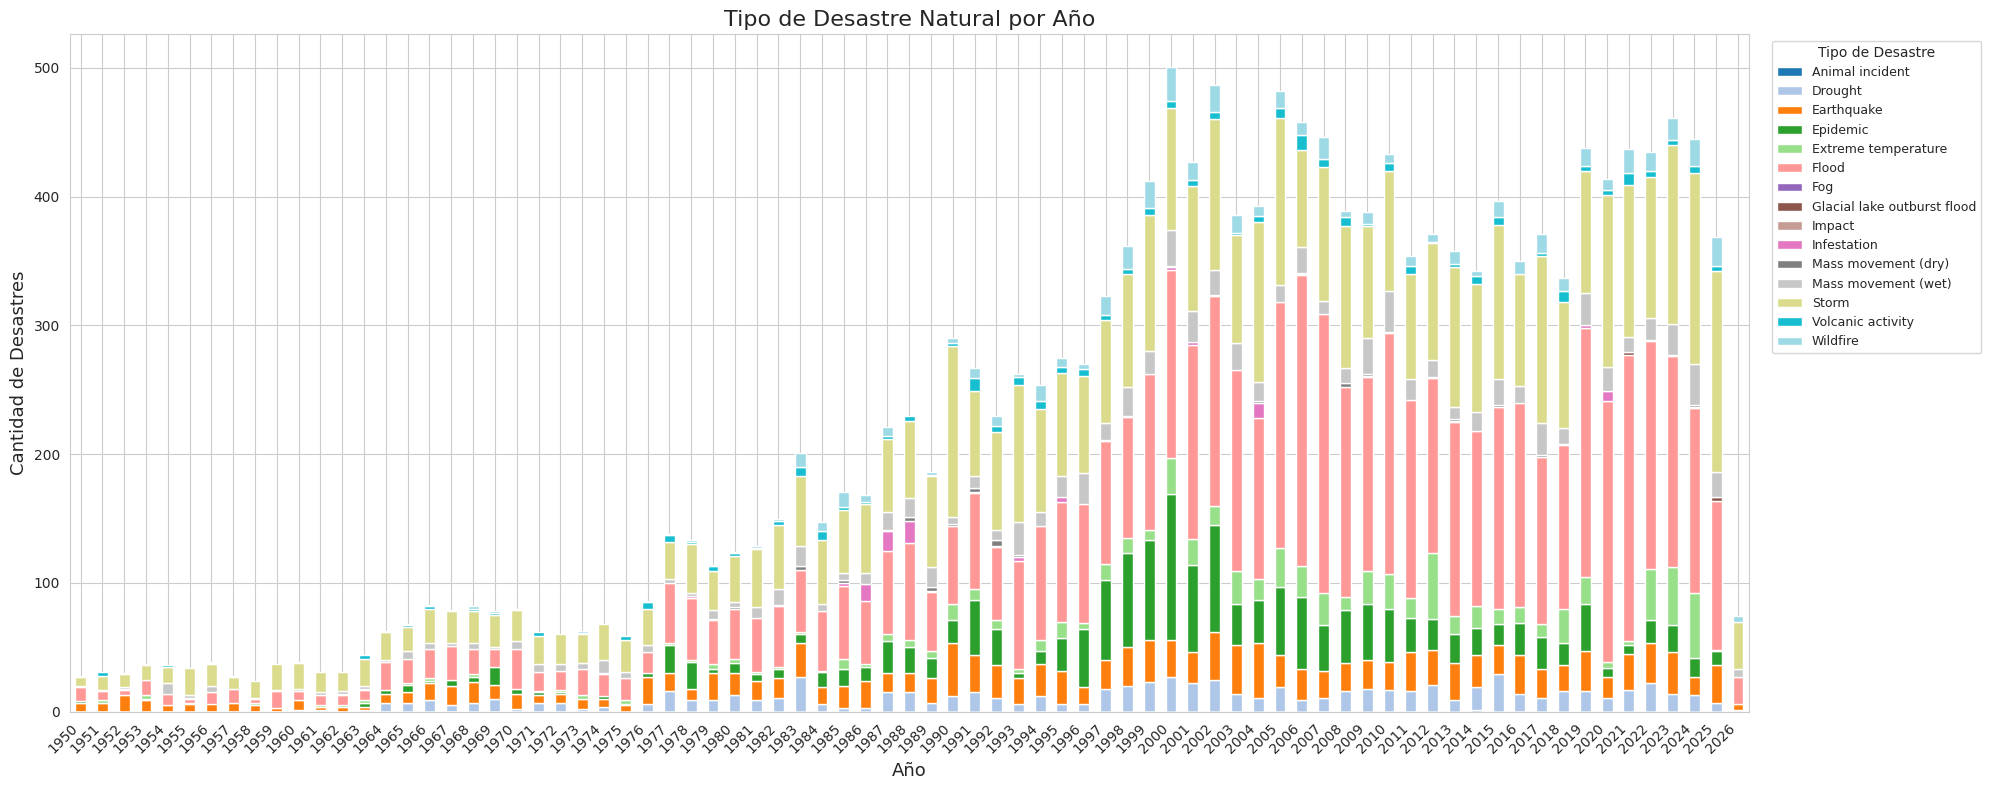

In [27]:
# Cargamos el dataset
df = pd.read_excel('sample_data/Natural-Disaster.xlsx')

# Agrupamos por año y tipo de desastre
df = df[df['Start Year'] >= 1950]
desastres_año_tipo = df.groupby(['Start Year', 'Disaster Type']).size().unstack(fill_value=0)

# Graficamos
desastres_año_tipo.plot(kind='bar', figsize=(20, 8), stacked=True, colormap='tab20')

plt.title('Tipo de Desastre Natural por Año', fontsize=16)
plt.xlabel('Año', fontsize=13)
plt.ylabel('Cantidad de Desastres', fontsize=13)
plt.legend(title='Tipo de Desastre', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Columnas usadas para clustering: ['Start Year', 'Duracion', 'Total Deaths', 'No. Injured', 'No. Homeless', 'No. Affected', 'Total Affected', "Total Damage ('000 US$)"]


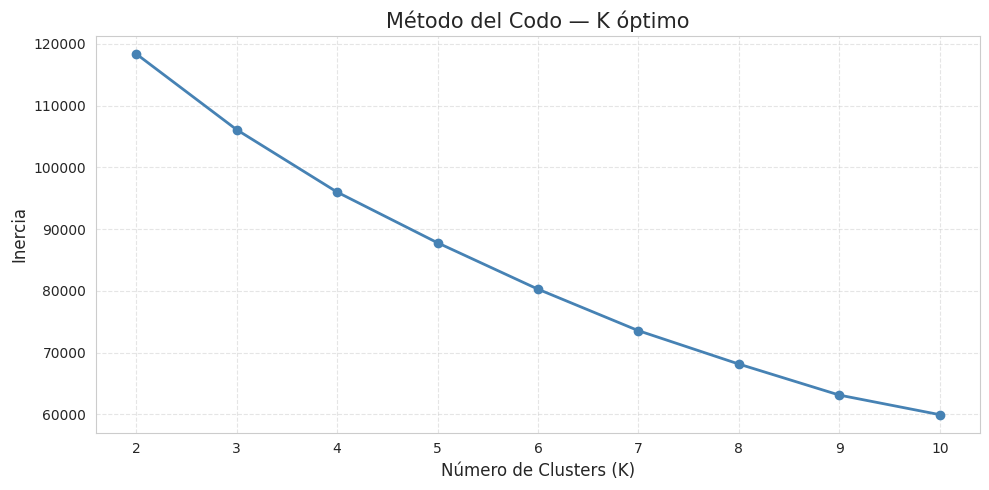

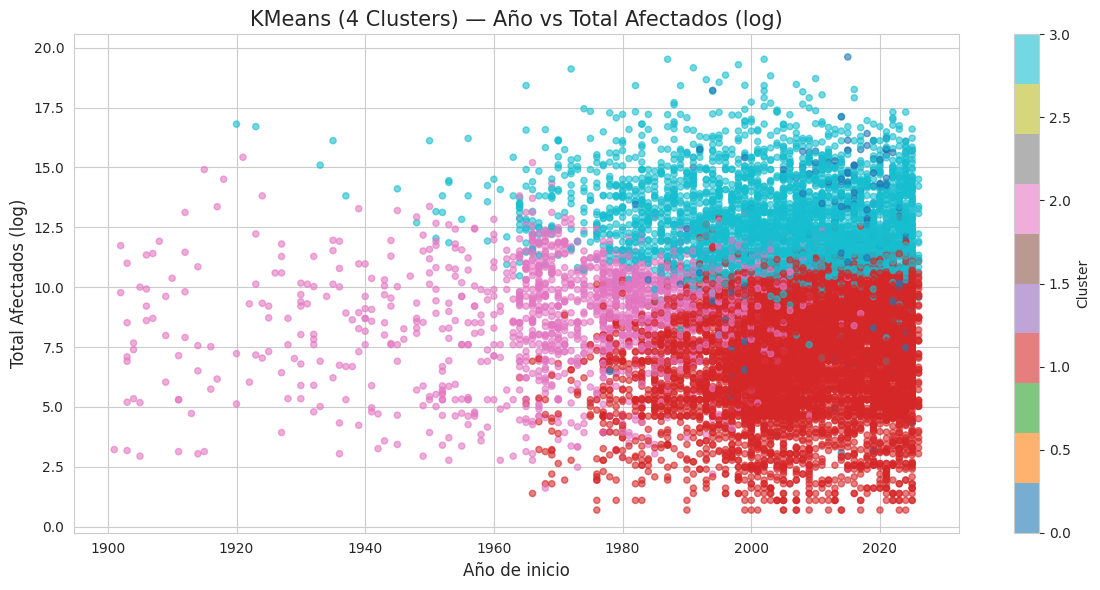

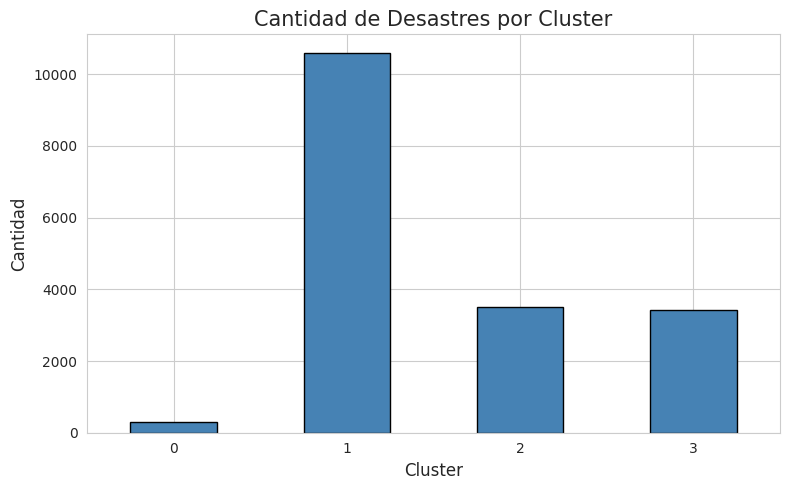


📊 Mediana por Cluster:
         Total Deaths  No. Affected  Total Affected  Total Damage ('000 US$)  Duracion
Cluster                                                                               
0               120.0      113401.0         35299.0                1100000.0      11.0
1                 9.0        2000.0          1500.0                 100000.0       0.0
2                67.0       15000.0         10005.0                   4130.5       0.0
3                49.0      282216.5        250055.0                 188500.0       0.0

🌍 Tipo de desastre más frecuente por Cluster:
Cluster
0    Epidemic
1       Flood
2       Storm
3       Flood

🗺️ Región más frecuente por Cluster:
Cluster
0    Africa
1      Asia
2      Asia
3      Asia


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── 1. Carga de datos ──────────────────────────────────────────────────────
df = pd.read_excel('sample_data/Natural-Disaster.xlsx')

# ── 2. Seleccionamos MÁS columnas para mejor agrupación ───────────────────
# Ahora incluimos: año, duración del desastre, muertes, afectados, heridos,
# sin hogar y daño económico
df['Duracion'] = df['End Year'] * 12 + df['End Month'] - (df['Start Year'] * 12 + df['Start Month'])
df['Duracion'] = df['Duracion'].clip(lower=0)  # evitar valores negativos

cols_cluster = [
    'Start Year',
    'Duracion',
    'Total Deaths',
    'No. Injured',
    'No. Homeless',
    'No. Affected',
    'Total Affected',
    "Total Damage ('000 US$)"
]

# Filtramos solo columnas que existen en el dataset
cols_cluster = [c for c in cols_cluster if c in df.columns]
print(f"Columnas usadas para clustering: {cols_cluster}")

df_cluster = df[cols_cluster].copy()

# ── 3. Imputamos nulos con la mediana ─────────────────────────────────────
imputer = SimpleImputer(strategy='median')
df_cluster_imp = pd.DataFrame(
    imputer.fit_transform(df_cluster),
    columns=cols_cluster
)

# ── 4. Aplicamos log1p a variables de impacto para reducir sesgo ──────────
cols_log = [c for c in cols_cluster if c != 'Start Year' and c != 'Duracion']
df_cluster_imp[cols_log] = np.log1p(df_cluster_imp[cols_log])

# ── 5. Estandarizamos ──────────────────────────────────────────────────────
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster_imp)

# ── 6. Método del Codo ────────────────────────────────────────────────────
inercias = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(rango_k, inercias, marker='o', color='steelblue', linewidth=2)
plt.title('Método del Codo — K óptimo', fontsize=15)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── 7. Entrenamos KMeans con K=4 (ajusta según el codo) ───────────────────
K_OPTIMO = 4  # <-- cambia este número según lo que veas en el gráfico

kmeans_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

# ── 8. Visualización 1: Año vs Total Afectados ────────────────────────────
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    df['Start Year'],
    np.log1p(df['Total Affected']),
    c=df['Cluster'],
    cmap='tab10',
    alpha=0.6,
    s=20
)
plt.colorbar(scatter, label='Cluster')
plt.title(f'KMeans ({K_OPTIMO} Clusters) — Año vs Total Afectados (log)', fontsize=15)
plt.xlabel('Año de inicio', fontsize=12)
plt.ylabel('Total Afectados (log)', fontsize=12)
plt.tight_layout()
plt.show()


# ── 10. Visualización 3: Cantidad de desastres por cluster ─────────────────
plt.figure(figsize=(8, 5))
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Cantidad de Desastres por Cluster', fontsize=15)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ── 11. Resumen estadístico por cluster ────────────────────────────────────
cols_resumen = ['Total Deaths', 'No. Affected', 'Total Affected', "Total Damage ('000 US$)", 'Duracion']
cols_resumen = [c for c in cols_resumen if c in df.columns]

resumen = df.groupby('Cluster')[cols_resumen].median().round(2)
print("\n📊 Mediana por Cluster:")
print(resumen.to_string())

# ── 12. Tipo de desastre más frecuente por cluster ─────────────────────────
print("\n🌍 Tipo de desastre más frecuente por Cluster:")
tipo_frecuente = df.groupby('Cluster')['Disaster Type'].agg(lambda x: x.value_counts().index[0])
print(tipo_frecuente.to_string())

# ── 13. Región más afectada por cluster ───────────────────────────────────
print("\n🗺️ Región más frecuente por Cluster:")
region_frecuente = df.groupby('Cluster')['Region'].agg(lambda x: x.value_counts().index[0])
print(region_frecuente.to_string())

INTERPRETACIÓN DE CLUSTERS:

Cluster 0 - Megadesastres biológicos:
  - Pocos eventos (~300) pero muy letales (120 muertes mediana)
  - Larga duración (11 meses en promedio)
  - Predominan epidemias en África
  - Mayor daño económico relativo

Cluster 1 - Desastres leves frecuentes:
  - El grupo más numeroso (~10.500 eventos)
  - Bajo impacto humano (9 muertes, 2.000 afectados)
  - Inundaciones de corta duración en Asia

Cluster 2 - Desastres moderados:
  - ~3.500 eventos con impacto intermedio
  - Tormentas en Asia con daño económico moderado

Cluster 3 - Desastres masivos en afectados:
  - ~3.400 eventos con altísima cantidad de afectados (282.216)
  - Inundaciones de gran escala en Asia
  - Relativamente pocas muertes pero enorme impacto poblacional